In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import sys
import importlib
if "helper" in sys.modules:
    importlib.reload(sys.modules["helper"])
if "plotting" in sys.modules:
    importlib.reload(sys.modules["plotting"])
import helper
import plotting
import importlib
import sys

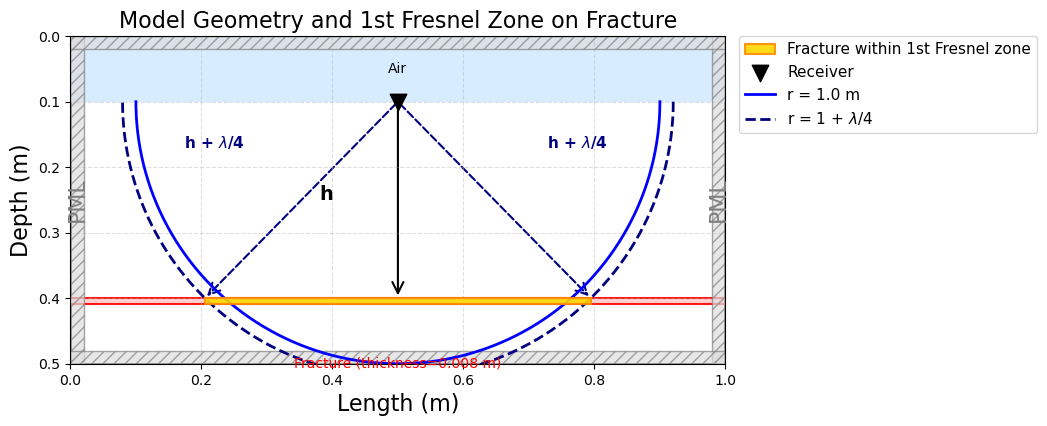

In [48]:
length = 1.0  # m
depth = 0.5   # m
x_receiver = 0.5  # m
y_receiver = 0.1  # m

f_central = 1.5e9  # Hz
epsilon_r = 6

fracture_thickness, wavelength = helper.max_fracture_thickness(f_central, epsilon_r, sub_wavelength_factor=10)
print(wavelength)

plotting.plot_model_geometry(length, depth, f_central, epsilon_r, fracture_thickness, x_receiver, y_receiver)

In [3]:
wavelength_ice = (((3.0 * 1e8) / np.sqrt(6) / 1.5e9))
wavelength_water = (((3.0 * 1e8) / np.sqrt(80) / 1.5e9))

aperture_ice = wavelength_ice / 10
aperture_water = wavelength_water / 10

dx_ice = aperture_ice / 10
dx_water = aperture_water / 10

area = 1.0 * 0.5

num_cells_ice = int(area / (dx_ice ** 2))
num_cells_water = int(area / (dx_water ** 2))

TWT_ice = (2 * 0.3) / (3.0 * 1e8 / np.sqrt(6))

print(f'Aperture (ice): {aperture_ice:.4f} m')
print(f'Aperture (water): {aperture_water:.4f} m')
print(f'Spatial step (ice): {dx_ice:.4f} m')
print(f'Spatial step (water): {dx_water:.4f} m')
print(f"Number of million cells (ice): {num_cells_ice / 1e6}")
print(f"Number of million cells (water): {num_cells_water / 1e6}")
print(f"Two-way travel time (ice): {TWT_ice * 1e9:.2f} ns")

Aperture (ice): 0.0082 m
Aperture (water): 0.0022 m
Spatial step (ice): 0.0008 m
Spatial step (water): 0.0002 m
Number of million cells (ice): 0.749999
Number of million cells (water): 10.0
Two-way travel time (ice): 4.90 ns


In [33]:
import os
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [109]:
baseline_model = r'..\True_and_Baseline_Models\baseline_model.in'

api(baseline_model, n=1, geometry_only=True)


=== Electromagnetic modelling software based on the Finite-Difference Time-Domain (FDTD) method 

    www.gprmax.com   __  __
     __ _ _ __  _ __|  \/  | __ ___  __
    / _` | '_ \| '__| |\/| |/ _` \ \/ /
   | (_| | |_) | |  | |  | | (_| |>  <
    \__, | .__/|_|  |_|  |_|\__,_/_/\_\\
    |___/|_|
                     v3.1.7 (Big Smoke)

 Copyright (C) 2015-2023: The University of Edinburgh
 Authors: Craig Warren and Antonis Giannopoulos

 gprMax is free software: you can redistribute it and/or modify it under the
  terms of the GNU General Public License as published by the Free Software
  Foundation, either version 3 of the License, or (at your option) any later
  version.
 gprMax is distributed in the hope that it will be useful, but WITHOUT ANY
  WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR
  A PARTICULAR PURPOSE.  See the GNU General Public License for more details.
 You should have received a copy of the GNU General Public License along with
  gp

c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


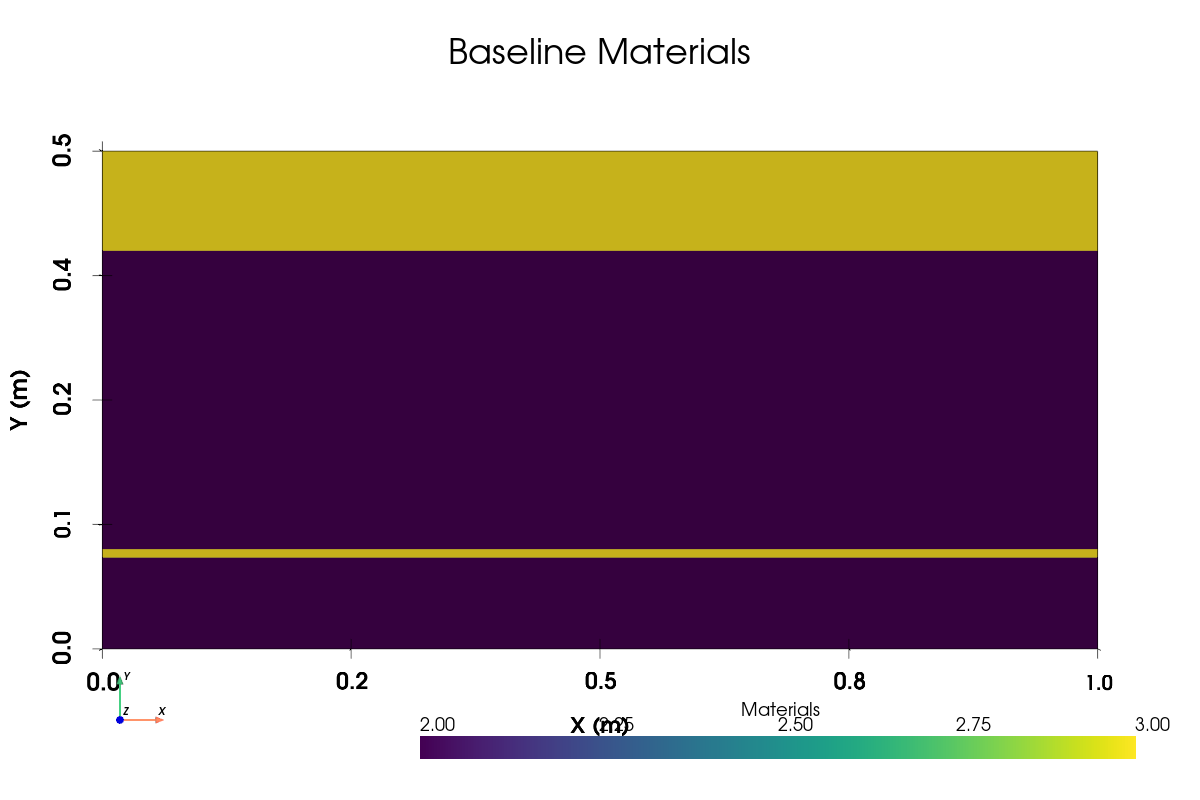

In [29]:
vti = r'..\True_and_Baseline_Models\Baseline_Model.vti'
import pyvista as pv
mesh = pv.read(vti)

# Create a larger plotter to accommodate grid
plotter = pv.Plotter(shape=(1, 1), window_size=(1200, 800))

# Camera position: (position, focal_point, view_up)
camera_pos = [(0.5, 0.25, 1.5), (0.5, 0.25, 0), (0, 1, 0)]

# Plot: Materials
plotter.subplot(0, 0)
plotter.add_mesh(mesh, scalars='Material', cmap='viridis', show_scalar_bar=True,
                 scalar_bar_args={'title': 'Materials'})
plotter.camera_position = camera_pos
plotter.add_title("Baseline Materials", font_size=14, color='black')
plotter.add_axes(labels_off=False)

# Add grid overlay with coordinates
plotter.show_grid(xtitle='X (m)', ytitle='Y (m)', ztitle='Z (m)', all_edges=True)

# Add domain dimensions text
plotter.add_text("Domain: 1.0 m × 0.5 m", position='upper_left', font_size=11, color='white')

plotter.show()


# Visualisation of Forward Modelling

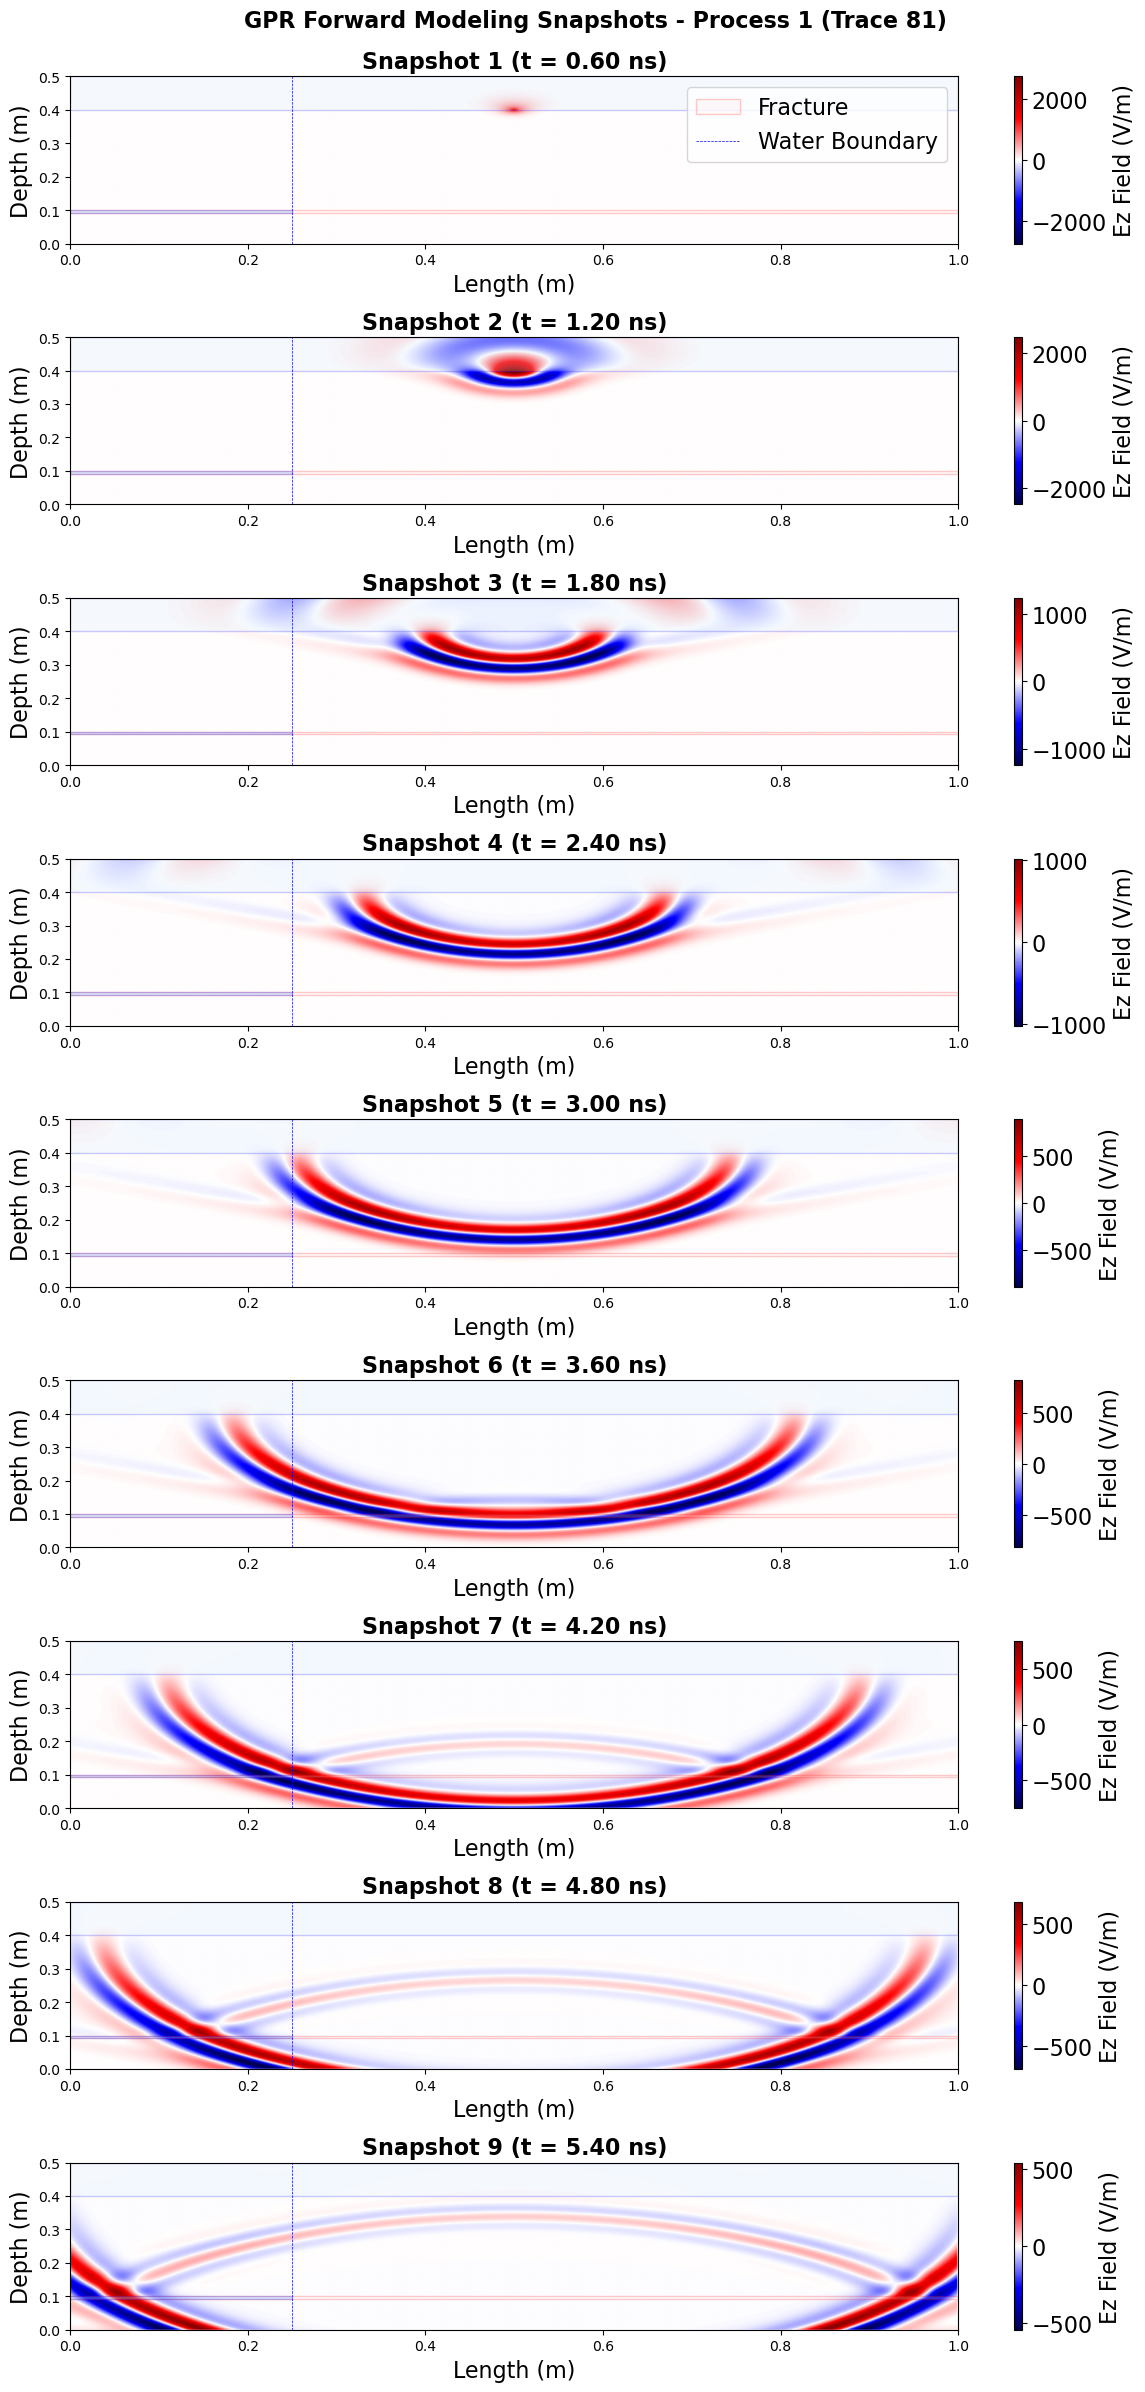

In [ ]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Model dimensions
length = 1.0   # x-length (m)
depth  = 0.5   # y-depth (m)
upper_layer_thickness = 0.1  # m
fracture_y0 = 0.0918
fracture_y1 = 0.1
water_boundary_x = 0.250  # m

# Path to snapshot folder
snapshot_folder = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\aperture_sweep_in_files\baseline_aperture_32of32_lambda_snaps'

# Select 8 evenly spaced snapshots from the 100 available
snapshot_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Create a figure with 8 subplots arranged vertically
fig, axes = plt.subplots(9, 1, figsize=(12, 24))

for i, (ax, snap_num) in enumerate(zip(axes, snapshot_indices)):
    # Read the VTI file
    snapshot_path = f'{snapshot_folder}\\snapshot{snap_num}.vti'
    mesh = pv.read(snapshot_path)
    
    # Get the mesh dimensions
    dims = mesh.dimensions
    
    # Check available field names
    field_name = 'E-field'  # This is a vector field with 3 components (Ex, Ey, Ez)
    
    if field_name in mesh.array_names:
        data = mesh[field_name]
        
        # E-field is a 3-component vector field
        # Reshape to get the grid: (nx-1) * (ny-1) * (nz-1) points, each with 3 components
        num_cells = (dims[0]-1) * (dims[1]-1) * (dims[2]-1)
        
        # Extract Ez component (index 2)
        if data.shape[1] == 3:  # Vector field with 3 components
            Ez_data = data[:, 2]  # Get z-component
        else:
            Ez_data = data.flatten()
        
        # Reshape to 2D grid (for 2D simulation, z-dimension is 1)
        data_2d = Ez_data.reshape(dims[1]-1, dims[0]-1)
        
        # Plot the data (without transpose)
        im = ax.imshow(data_2d, aspect='auto', cmap='seismic', origin='lower',
                      vmin=-np.abs(data_2d).max(), vmax=np.abs(data_2d).max(),
                      extent=[0, length, 0, depth])
        
        # Calculate time for this snapshot (5e-11 s per snapshot)
        time_ns = snap_num * 6e-10 * 1e9
        
        ax.set_title(f'Snapshot {snap_num} (t = {time_ns:.2f} ns)', fontsize=16, weight='bold')
        ax.set_xlabel('Length (m)', fontsize=16)
        ax.set_ylabel('Depth (m)', fontsize=16)
        
        # Upper layer (top)
        ax.add_patch(Rectangle((0, depth - upper_layer_thickness), length, upper_layer_thickness,
                               facecolor='#cfe8ff', edgecolor='blue', alpha=0.2))
        
        # Fracture zone
        ax.add_patch(Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                               facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.2,
                               label='Fracture' if i == 0 else ''))
        
        # Water boundary line at x = 0.250 m
        ax.axvline(x=water_boundary_x, color='blue', linestyle='--', linewidth=0.5,
                  label='Water Boundary' if i == 0 else '')
        
        # Water front (filled portion)
        if water_boundary_x > 0:
            ax.add_patch(Rectangle((0, fracture_y0), water_boundary_x, fracture_y1 - fracture_y0,
                                facecolor='#4da3ff', edgecolor='blue', alpha=0.2))
        
        # Add legend to first subplot only
        if i == 0:
            ax.legend(loc='upper right', fontsize=16)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Ez Field (V/m)')
        cbar.ax.tick_params(labelsize=16)
        cbar.set_label('Ez Field (V/m)', fontsize=16)
        
    else:
        ax.text(0.5, 0.5, f'Field {field_name} not found\nAvailable: {mesh.array_names}',
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('GPR Forward Modeling Snapshots - Process 1 (Trace 81)', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()

# # save image
# path = 'Images_Experiment_9\\Results\\Raw\\Snapshots_Process_1.png'
# plt.savefig(fname = path, bbox_inches='tight')

plt.show()

In [16]:
rxnumber = 1
rxcomponent = 'Ez'
baseline_results = r'..\True_and_Baseline_Models\baseline_model.out'
process_results  = r'..\True_and_Baseline_Models\process_model.out'

baseline_data, dt = get_output_data(baseline_results, rxnumber, rxcomponent)
process_data, dt  = get_output_data(process_results, rxnumber, rxcomponent)

# Tuning Effect Model

In [5]:
# Aperture sweep file generator: create one .in file per aperture thickness
from pathlib import Path
import numpy as np
import pandas as pd

epsilon_r = 6 # Relative permittivity
f_central = 1.5e9 # Hz

# Uses wavelength computed earlier in the notebook. If unavailable, compute from current model settings.
if 'wavelength' not in globals():
    c0 = 3.0e8
    wavelength = c0 / (np.sqrt(epsilon_r) * f_central)

# Fractions: 32/32, 31/32, ..., 1/32
fractions = np.arange(32, 0, -1) / 32.0
aperture_thickness_values = wavelength * fractions

# Input template and output folder
template_in = Path('..') / 'True_and_Baseline_Models' / 'baseline_model.in'
output_folder = Path('..') / 'True_and_Baseline_Models' / 'aperture_sweep_in_files'
output_folder.mkdir(parents=True, exist_ok=True)

# Read baseline template
lines = template_in.read_text(encoding='utf-8').splitlines()

# Locate the thin-fracture box line (line directly below '// Thin fracture')
fracture_comment_idx = None
for i, line in enumerate(lines):
    if line.strip() == '// Thin fracture':
        fracture_comment_idx = i
        break

if fracture_comment_idx is None or fracture_comment_idx + 1 >= len(lines):
    raise ValueError("Could not locate '// Thin fracture' section in baseline_model.in")

fracture_box_idx = fracture_comment_idx + 1
if not lines[fracture_box_idx].strip().startswith('#box:'):
    raise ValueError("Expected a #box line immediately after '// Thin fracture'")

# Keep fracture top fixed; update aperture by moving fracture bottom
fracture_top_y = 0.1

generated_rows = []
for frac, aperture_thickness in zip(fractions, aperture_thickness_values):
    fracture_bottom_y = fracture_top_y - float(aperture_thickness)

    if fracture_bottom_y < 0:
        raise ValueError(
            f"Invalid aperture ({aperture_thickness:.6e} m): fracture bottom below domain."
        )

    updated_lines = lines.copy()
    updated_lines[fracture_box_idx] = (
        f"#box: 0 {fracture_bottom_y:.6f} 0 1.0 {fracture_top_y:.6f} 0.0002 air"
    )

    # Logical filename example: baseline_aperture_31of32_lambda.in
    numerator = int(round(frac * 32))
    out_name = f"baseline_aperture_{numerator:02d}of32_lambda.in"
    out_path = output_folder / out_name
    out_path.write_text('\n'.join(updated_lines) + '\n', encoding='utf-8')

    generated_rows.append({
        'fraction_of_wavelength': frac,
        'aperture_thickness_m': float(aperture_thickness),
        'fracture_bottom_y_m': fracture_bottom_y,
        'output_file': str(out_path)
    })

aperture_sweep_table = pd.DataFrame(generated_rows)

print(f"Wavelength = {wavelength:.6e} m")
print(f"Generated {len(aperture_sweep_table)} input files in: {output_folder}")
print(aperture_sweep_table[['fraction_of_wavelength', 'aperture_thickness_m', 'fracture_bottom_y_m']].to_string(index=False))

Wavelength = 8.159317e-02 m
Generated 32 input files in: ..\True_and_Baseline_Models\aperture_sweep_in_files
 fraction_of_wavelength  aperture_thickness_m  fracture_bottom_y_m
                1.00000              0.081593             0.018407
                0.96875              0.079043             0.020957
                0.93750              0.076494             0.023506
                0.90625              0.073944             0.026056
                0.87500              0.071394             0.028606
                0.84375              0.068844             0.031156
                0.81250              0.066294             0.033706
                0.78125              0.063745             0.036255
                0.75000              0.061195             0.038805
                0.71875              0.058645             0.041355
                0.68750              0.056095             0.043905
                0.65625              0.053546             0.046454
                0.62

In [36]:
aperture_model_thinnest = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\aperture_sweep_in_files\baseline_aperture_01of32_lambda.in'
aperture_model_thickest = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\aperture_sweep_in_files\baseline_aperture_32of32_lambda.in'

api(aperture_model_thinnest, n=1, geometry_only=True)
api(aperture_model_thickest, n=1, geometry_only=True)

c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


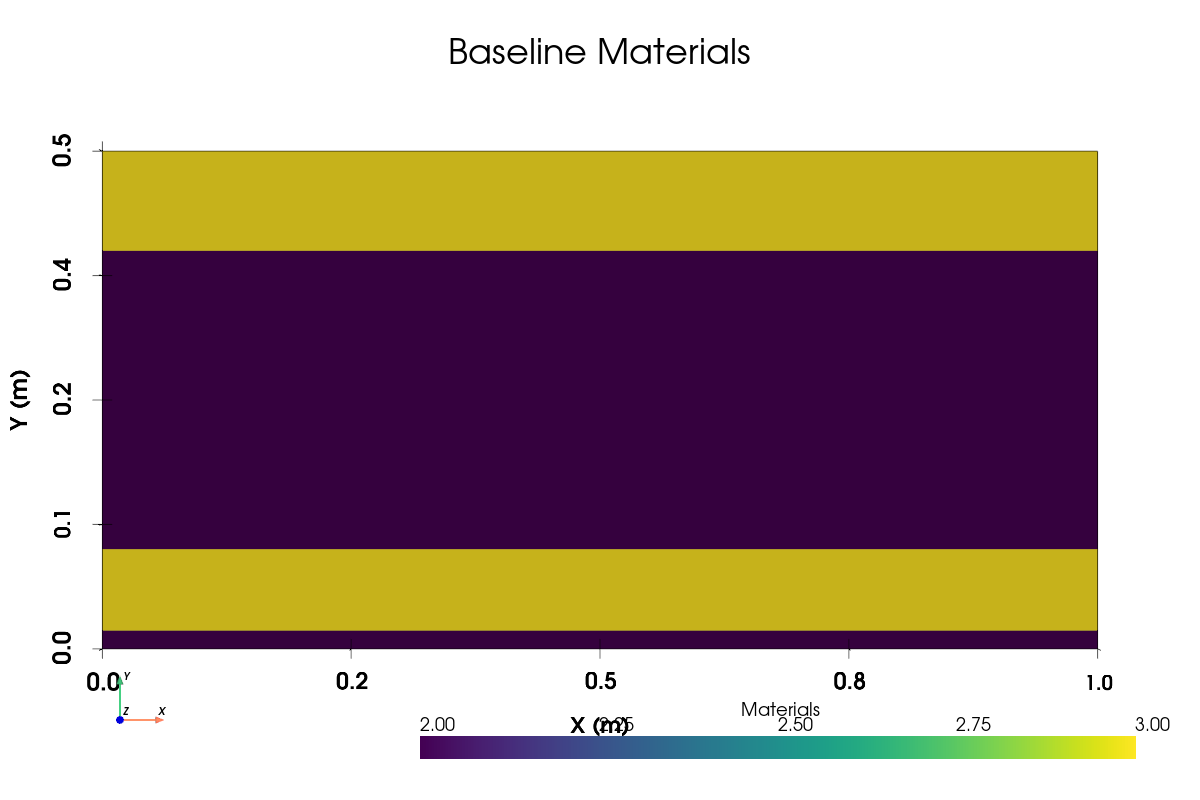

In [50]:
vti_thinnest = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\aperture_sweep_in_files\aperture_01of32.vti'
vti_thickest = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\aperture_sweep_in_files\aperture_32of32.vti'
import pyvista as pv
mesh = pv.read(vti_thickest)

# Create a larger plotter to accommodate grid
plotter = pv.Plotter(shape=(1, 1), window_size=(1200, 800))

# Camera position: (position, focal_point, view_up)
camera_pos = [(0.5, 0.25, 1.5), (0.5, 0.25, 0), (0, 1, 0)]

# Plot: Materials
plotter.subplot(0, 0)
plotter.add_mesh(mesh, scalars='Material', cmap='viridis', show_scalar_bar=True,
                 scalar_bar_args={'title': 'Materials'})
plotter.camera_position = camera_pos
plotter.add_title("Baseline Materials", font_size=14, color='black')
plotter.add_axes(labels_off=False)

# Add grid overlay with coordinates
plotter.show_grid(xtitle='X (m)', ytitle='Y (m)', ztitle='Z (m)', all_edges=True)

# Add domain dimensions text
plotter.add_text("Domain: 1.0 m × 0.5 m", position='upper_left', font_size=11, color='white')

plotter.show()


In [16]:
# GPU preflight for subprocess execution (matches terminal workflow)
import os
import sys
import shutil
import subprocess
import json
from pathlib import Path

gpu_device_id = 0  # Keep consistent with Cell 13

vcvars_candidates = [
    os.environ.get('VCVARS64_BAT', '').strip(),
    r'C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Progra~2\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
]

def build_gprmax_env(vcvars_paths):
    """Return environment dict hydrated by vcvars64.bat when available."""
    merged_env = os.environ.copy()
    for candidate in vcvars_paths:
        if not candidate or not os.path.exists(candidate):
            continue

        # Match known-good terminal pattern: cmd /c '"<vcvars64.bat>" && set'
        cmd_text = f'"{candidate}" && set'
        env_dump = subprocess.run(
            ['cmd', '/c', cmd_text],
            capture_output=True,
            text=True
        )

        if env_dump.returncode == 0:
            loaded = 0
            for line in env_dump.stdout.splitlines():
                if '=' in line:
                    key, value = line.split('=', 1)
                    merged_env[key] = value
                    loaded += 1
            print(f'Loaded Visual Studio build environment from: {candidate} ({loaded} variables)')
            return merged_env

        print(f'vcvars64 exists but failed to load: {candidate}')
        if env_dump.stderr.strip():
            print(f'vcvars64 error: {env_dump.stderr.strip()}')

    print('No usable vcvars64.bat found; continuing with current environment only.')
    return merged_env

def probe_modules(python_cmd: str, env: dict):
    """Check whether gprMax and pycuda are importable in a given Python command."""
    probe_code = (
        "import importlib.util as u, json; "
        "print(json.dumps({'gprMax': bool(u.find_spec('gprMax')), 'pycuda': bool(u.find_spec('pycuda'))}))"
    )
    proc = subprocess.run(
        [python_cmd, '-c', probe_code],
        capture_output=True,
        text=True,
        env=env
    )
    if proc.returncode != 0:
        return None
    try:
        return json.loads(proc.stdout.strip())
    except json.JSONDecodeError:
        return None

nvidia_smi = shutil.which('nvidia-smi')
if nvidia_smi is None:
    raise EnvironmentError(
        'nvidia-smi not found. NVIDIA driver/CUDA runtime is not available in this environment.'
    )

print(f'nvidia-smi found at: {nvidia_smi}')
query_cmd = [
    nvidia_smi,
    '--query-gpu=index,name,memory.total,driver_version',
    '--format=csv,noheader'
]
result = subprocess.run(query_cmd, capture_output=True, text=True, check=True)
gpu_lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
if not gpu_lines:
    raise RuntimeError('No GPUs reported by nvidia-smi.')

print('Detected GPUs:')
for line in gpu_lines:
    print(f' - {line}')

if gpu_device_id >= len(gpu_lines):
    raise ValueError(
        f'gpu_device_id={gpu_device_id} is out of range. Available GPU indices: 0..{len(gpu_lines)-1}'
    )

# Make selected GPU explicit for subprocess execution
os.environ['CUDA_VISIBLE_DEVICES'] = str(gpu_device_id)
print(f'Using GPU index: {gpu_device_id} (CUDA_VISIBLE_DEVICES={os.environ["CUDA_VISIBLE_DEVICES"]})')

gprmax_env = build_gprmax_env(vcvars_candidates)
gprmax_env['CUDA_VISIBLE_DEVICES'] = str(gpu_device_id)

python_candidates = []
python_env_override = os.environ.get('GPRMAX_PYTHON_CMD', '').strip()
if python_env_override:
    python_candidates.append(python_env_override)

python_candidates.extend([
    sys.executable,
    str(Path.home() / 'miniconda3' / 'envs' / 'gprMaxCuda' / 'python.exe'),
    str(Path.home() / 'miniconda3' / 'envs' / 'gprMax' / 'python.exe'),
    'python',
])

seen = set()
module_report = {}
selected_python = None

for py_cmd in python_candidates:
    if not py_cmd or py_cmd in seen:
        continue
    seen.add(py_cmd)

    if py_cmd.endswith('.exe') and not os.path.exists(py_cmd):
        continue

    availability = probe_modules(py_cmd, gprmax_env)
    if availability is None:
        module_report[py_cmd] = {'gprMax': False, 'pycuda': False, 'probe': 'failed'}
        continue

    module_report[py_cmd] = availability
    print(f"Probe {py_cmd}: gprMax={availability['gprMax']}, pycuda={availability['pycuda']}")

    if availability['gprMax'] and availability['pycuda'] and selected_python is None:
        selected_python = py_cmd

if selected_python is None:
    print('Interpreter probe summary:')
    for py_cmd, status in module_report.items():
        print(f' - {py_cmd}: {status}')
    raise RuntimeError(
        'No tested Python interpreter had both gprMax and pycuda available. '
        'Set GPRMAX_PYTHON_CMD to a known-good interpreter and rerun Cell 12.'
    )

gprmax_python_cmd = selected_python
print(f'Selected Python command for gprMax runs: {gprmax_python_cmd}')

nvidia-smi found at: C:\windows\system32\nvidia-smi.EXE
Detected GPUs:
 - 0, NVIDIA GeForce RTX 5060, 8151 MiB, 580.88
Using GPU index: 0 (CUDA_VISIBLE_DEVICES=0)
vcvars64 exists but failed to load: C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat
vcvars64 error: '\"C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat\"' is not recognized as an internal or external command,
operable program or batch file.
vcvars64 exists but failed to load: C:\Progra~2\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat
vcvars64 error: '\"C:\Progra~2\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat\"' is not recognized as an internal or external command,
operable program or batch file.
No usable vcvars64.bat found; continuing with current environment only.
Probe c:\Users\Administrator\miniconda3\envs\gprMax\python.exe: gprMax=True, pycuda=True
Probe C:\Users\Administrator\m

In [17]:
# Run all generated aperture sweep input files with gprMax via subprocess (GPU only)
from pathlib import Path
import subprocess
import os

# Folder created in Cell 11
sweep_folder = Path('..') / 'True_and_Baseline_Models' / 'aperture_sweep_in_files'
input_files = sorted(sweep_folder.glob('baseline_aperture_*of32_lambda.in'))

if not input_files:
    raise FileNotFoundError(f'No generated .in files found in: {sweep_folder}')

if 'gprmax_python_cmd' not in globals():
    raise RuntimeError('Run Cell 12 first to configure GPU environment.')

# Optional quick test: set to an integer (e.g., 1 or 2) before full sweep
max_runs = None
if max_runs is not None:
    input_files = input_files[:int(max_runs)]

vcvars_candidates = [
    os.environ.get('VCVARS64_BAT', '').strip(),
    r'C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Progra~2\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
]
vcvars_bat = next((p for p in vcvars_candidates if p and os.path.exists(p)), None)

print(f'Found {len(input_files)} input files.')
print(f'Using Python: {gprmax_python_cmd}')
print(f'Using vcvars64: {vcvars_bat if vcvars_bat else "not found"}')

def run_one_model(in_file: Path):
    if vcvars_bat:
        # Use the same VS env bootstrap pattern that works in terminal.
        ps_script = (
            f"$envDump = cmd /c '\"{vcvars_bat}\" && set'; "
            "$envDump | ForEach-Object { $p = $_ -split '=',2; if($p.Length -eq 2){ Set-Item -Path env:$($p[0]) -Value $p[1] } }; "
            "cl /? > $null; "
            f"& '{gprmax_python_cmd}' -m gprMax '{in_file}' -n 1 -gpu {gpu_device_id}"
        )
        return subprocess.run(
            ['powershell', '-NoProfile', '-Command', ps_script],
            capture_output=True,
            text=True
        )

    # Fallback when vcvars isn't present
    cmd = [
        gprmax_python_cmd,
        '-m', 'gprMax',
        str(in_file),
        '-n', '1',
        '-gpu', str(gpu_device_id),
    ]
    return subprocess.run(cmd, capture_output=True, text=True)

run_results = []
for idx, in_file in enumerate(input_files, start=1):
    print(f'[{idx}/{len(input_files)}] Running on GPU {gpu_device_id}: {in_file.name}')
    proc = run_one_model(in_file)

    if proc.returncode == 0:
        run_results.append((in_file.name, 'OK'))
    else:
        err_tail = (proc.stderr or proc.stdout).strip().splitlines()
        err_tail = '\n'.join(err_tail[-8:]) if err_tail else 'No output captured.'
        run_results.append((in_file.name, f'FAILED: {err_tail}'))
        print(f'FAILED: {in_file.name}')
        print(err_tail)

num_ok = sum(1 for _, status in run_results if status == 'OK')
num_failed = len(run_results) - num_ok

print(f'Run complete. Successful: {num_ok}, Failed: {num_failed}')
if num_failed > 0:
    print('Failed files:')
    for fname, status in run_results:
        if status != 'OK':
            print(f' - {fname}: {status}')

Found 32 input files.
Using Python: c:\Users\Administrator\miniconda3\envs\gprMax\python.exe
Using vcvars64: C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat
[1/32] Running on GPU 0: baseline_aperture_01of32_lambda.in
[2/32] Running on GPU 0: baseline_aperture_02of32_lambda.in
[3/32] Running on GPU 0: baseline_aperture_03of32_lambda.in
[4/32] Running on GPU 0: baseline_aperture_04of32_lambda.in
[5/32] Running on GPU 0: baseline_aperture_05of32_lambda.in
[6/32] Running on GPU 0: baseline_aperture_06of32_lambda.in
[7/32] Running on GPU 0: baseline_aperture_07of32_lambda.in
[8/32] Running on GPU 0: baseline_aperture_08of32_lambda.in
[9/32] Running on GPU 0: baseline_aperture_09of32_lambda.in
[10/32] Running on GPU 0: baseline_aperture_10of32_lambda.in
[11/32] Running on GPU 0: baseline_aperture_11of32_lambda.in
[12/32] Running on GPU 0: baseline_aperture_12of32_lambda.in
[13/32] Running on GPU 0: baseline_aperture_13of32_lambda.in
[14/32] Runn

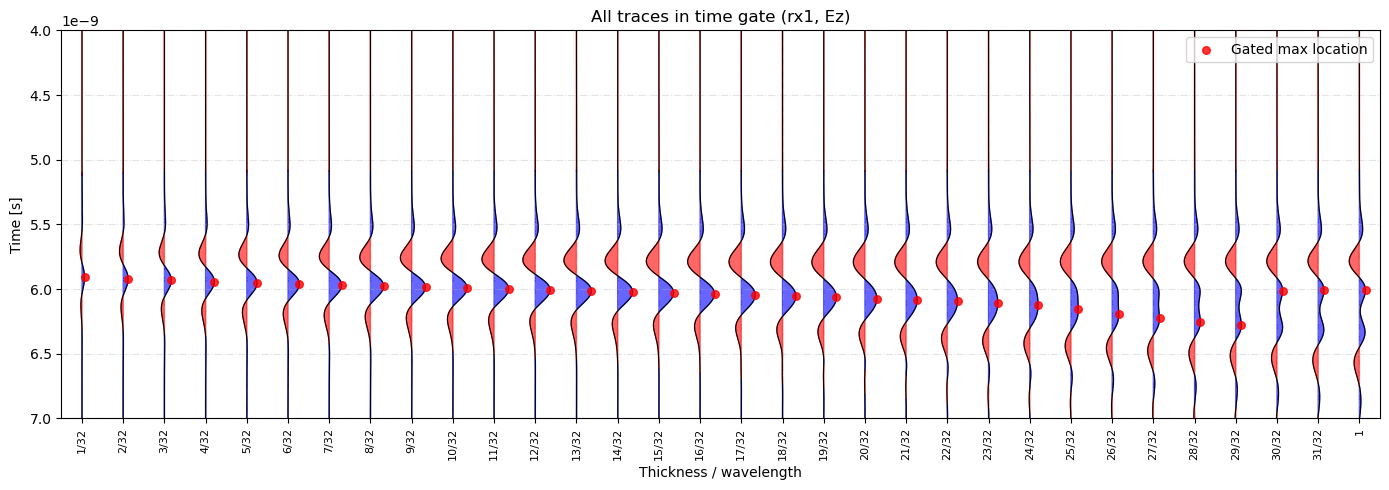

Full matrix shape=(14840, 32), gated shape=(6359, 32), robust_amp=3.514e+02, scale=1.081e-03, per-trace p99 ratio=5.88


In [10]:
# Seismic-style wiggle plot for all aperture-model A-scans
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

if 'get_output_data' not in globals():
    from tools.plot_Bscan import get_output_data

rxnumber = 1
rxcomponent = 'Ez'
t_min = 4e-9   # 5 ns
t_max = 7e-9   # 7 ns
scale_percentile = 99.0
skip_first_trace = False  # Set True if first trace is a reference trace

out_folder = Path('..') / 'True_and_Baseline_Models' / 'aperture_sweep_in_files'
out_files = sorted(
    out_folder.glob('baseline_aperture_*of32_lambda.out'),
    key=lambda p: int(re.search(r'baseline_aperture_(\d+)of32_lambda\.out$', p.name).group(1))
    if re.search(r'baseline_aperture_(\d+)of32_lambda\.out$', p.name) else 10**9
)

if len(out_files) < 2:
    raise ValueError(f'Need at least 2 traces. Found {len(out_files)} in {out_folder}')

if skip_first_trace:
    out_files = out_files[1:]

traces = []
aperture_fraction = []
dt = None

for f in out_files:
    data, dt_i = get_output_data(str(f), rxnumber, rxcomponent)
    trace = np.ravel(np.asarray(data, dtype=float))
    if trace.size == 0:
        continue

    m = re.search(r'baseline_aperture_(\d+)of32_lambda\.out$', f.name)
    if not m:
        continue

    num = int(m.group(1))
    aperture_fraction.append(num / 32.0)
    traces.append(trace)

    if dt is None:
        dt = float(dt_i)

if not traces:
    raise RuntimeError('No valid traces were loaded from aperture .out files.')

min_len = min(len(tr) for tr in traces)
if len({len(tr) for tr in traces}) > 1:
    traces = [tr[:min_len] for tr in traces]

# Matrix representation for downstream processing (samples x traces)
trace_matrix_full = np.column_stack(traces)
t_full = np.arange(trace_matrix_full.shape[0]) * dt
aperture_fraction = np.asarray(aperture_fraction, dtype=float)

# Time gate
time_mask = (t_full >= t_min) & (t_full <= t_max)
trace_matrix = trace_matrix_full[time_mask, :]
t = t_full[time_mask]

if trace_matrix.size == 0:
    raise RuntimeError('Selected time gate is empty. Adjust t_min and t_max.')

# Robust global scaling (no clipping) preserves relative amplitude differences
robust_amp = np.percentile(np.abs(trace_matrix), scale_percentile)
scale = 0.38 / robust_amp if robust_amp > 0 else 1.0
wiggles = trace_matrix * scale

# Export matrices for ObsPy time-frequency analysis
wiggle_matrix_full = trace_matrix_full.copy()
wiggle_matrix = trace_matrix.copy()
wiggle_time_full = t_full.copy()
wiggle_time = t.copy()
wiggle_dt = float(dt)
wiggle_aperture_fraction = aperture_fraction.copy()

trace_p99 = np.percentile(np.abs(trace_matrix), scale_percentile, axis=0)
amp_ratio = (np.max(trace_p99) / np.min(trace_p99)) if np.min(trace_p99) > 0 else np.inf

spacing = np.mean(np.diff(aperture_fraction)) if len(aperture_fraction) > 1 else 0.05

fig = plt.figure(figsize=(14, 5), facecolor='w', edgecolor='w')
for i in range(wiggles.shape[1]):
    baseline = aperture_fraction[i]
    x = baseline + wiggles[:, i] * spacing * 0.8

    plt.plot(x, t, color='black', linewidth=0.8)
    plt.fill_betweenx(
        t, baseline, x,
        where=(wiggles[:, i] >= 0),
        color='blue', alpha=0.6, interpolate=True
    )
    plt.fill_betweenx(
        t, baseline, x,
        where=(wiggles[:, i] < 0),
        color='red', alpha=0.6, interpolate=True
    )

# Mark gated max locations with scatter dots
max_x = []
max_t = []
for i in range(trace_matrix.shape[1]):
    max_idx = np.argmax(trace_matrix[:, i])
    max_x.append(aperture_fraction[i] + wiggles[max_idx, i] * spacing * 0.8)
    max_t.append(t[max_idx])

plt.scatter(max_x, max_t, color='red', s=30, zorder=5, alpha=0.8, label='Gated max location')
plt.gca().invert_yaxis()
plt.xlim(aperture_fraction[0] - spacing * 0.5, aperture_fraction[-1] + spacing * 0.5)
plt.ylim(t_max, t_min)

# Fraction notation ticks: 1/32, 2/32, ..., 31/32, 1
tick_nums = np.arange(1, 33)
tick_positions = tick_nums / 32.0
tick_labels = [f'{n}/32' if n < 32 else '1' for n in tick_nums]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=8)

plt.xlabel('Thickness / wavelength' + (' (reference skipped)' if skip_first_trace else ''))
plt.ylabel('Time [s]')
plt.title(f'All traces in time gate (rx{rxnumber}, {rxcomponent})')
plt.grid(True, linestyle='-.', alpha=0.35)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(
    f'Full matrix shape={wiggle_matrix_full.shape}, gated shape={wiggle_matrix.shape}, '
    f'robust_amp={robust_amp:.3e}, scale={scale:.3e}, per-trace p99 ratio={amp_ratio:.2f}'
)

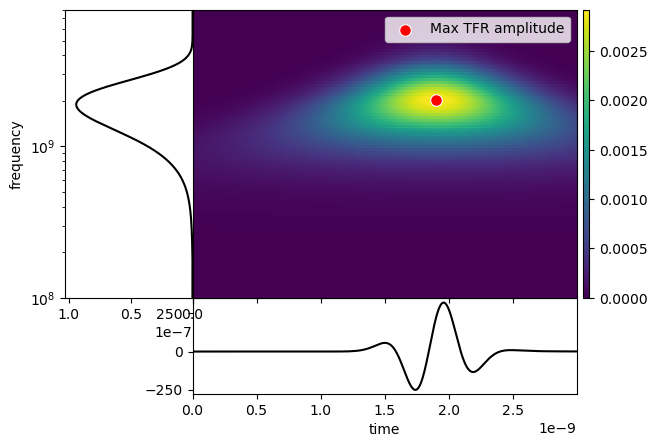

Using wiggle_matrix[:, 5] for TFR, n_samples=6359, dt=4.717e-13 s, fmin=1.00e+08 Hz, fmax=8.00e+09 Hz, nf=100
Max TFR amplitude at time=1.902e-09 s, frequency=2.028e+09 Hz, value=2.919e-03


In [27]:
from obspy.signal.tf_misfit import plot_tfr, cwt
import matplotlib.pyplot as plt
import numpy as np

if 'wiggle_matrix' not in globals() or 'wiggle_dt' not in globals():
    raise RuntimeError('Run Cell 14 first to create wiggle matrices.')

trace_index = 5  # 0-based index into matrix columns
fmin = 1e8
fmax = 8e9
nf = 100
w0 = 6

if trace_index < 0 or trace_index >= wiggle_matrix.shape[1]:
    raise ValueError(f'trace_index {trace_index} out of range for {wiggle_matrix.shape[1]} traces.')

st1 = wiggle_matrix[:, trace_index]
dt = wiggle_dt
time_vec = np.arange(st1.size) * dt

# Compute time-frequency matrix directly for an exact max (time, frequency) pick.
tf_complex = cwt(st1, dt=dt, w0=w0, fmin=fmin, fmax=fmax, nf=nf)
tf_amp = np.abs(tf_complex)
max_flat_idx = int(np.argmax(tf_amp))
max_f_idx, max_t_idx = np.unravel_index(max_flat_idx, tf_amp.shape)

# cwt frequencies are logarithmically spaced between fmin and fmax
freq_vec = np.logspace(np.log10(fmin), np.log10(fmax), nf)
max_t = time_vec[max_t_idx]
max_f = freq_vec[max_f_idx]
max_tf_amp = tf_amp[max_f_idx, max_t_idx]

# Keep plot style consistent with ObsPy utility and overlay exact TFR max location.
fig = plot_tfr(
    st1, dt=dt, fmin=fmin, fmax=fmax,
    fft_zero_pad_fac=5000,
    show=False
)

if len(fig.axes) == 0:
    raise RuntimeError('plot_tfr returned a figure without axes.')

# Select the heatmap axis (usually has QuadMesh in collections or image artists).
heat_axes = [ax for ax in fig.axes if len(ax.collections) > 0 or len(ax.images) > 0]
if not heat_axes:
    raise RuntimeError('Could not find TFR heatmap axis to annotate.')

# Prefer the heat axis with log-frequency y-scale.
tfr_ax = next((ax for ax in heat_axes if ax.get_yscale() == 'log'), heat_axes[0])

tfr_ax.scatter(
    [max_t], [max_f],
    color='red', s=70, zorder=12,
    edgecolors='white', linewidths=0.8,
    label='Max TFR amplitude'
 )
tfr_ax.legend(loc='upper right')

plt.show()

print(
    f'Using wiggle_matrix[:, {trace_index}] for TFR, '
    f'n_samples={st1.size}, dt={dt:.3e} s, fmin={fmin:.2e} Hz, fmax={fmax:.2e} Hz, nf={nf}'
 )
print(
    f'Max TFR amplitude at time={max_t:.3e} s, frequency={max_f:.3e} Hz, value={max_tf_amp:.3e}'
 )

Trace  0 (aperture 0.0312): max TFR amplitude = 6.357e-04
Trace  1 (aperture 0.0625): max TFR amplitude = 1.235e-03
Trace  2 (aperture 0.0938): max TFR amplitude = 1.733e-03
Trace  3 (aperture 0.1250): max TFR amplitude = 2.207e-03
Trace  4 (aperture 0.1562): max TFR amplitude = 2.610e-03
Trace  5 (aperture 0.1875): max TFR amplitude = 2.919e-03
Trace  6 (aperture 0.2188): max TFR amplitude = 3.193e-03
Trace  7 (aperture 0.2500): max TFR amplitude = 3.416e-03
Trace  8 (aperture 0.2812): max TFR amplitude = 3.596e-03
Trace  9 (aperture 0.3125): max TFR amplitude = 3.726e-03
Trace 10 (aperture 0.3438): max TFR amplitude = 3.833e-03
Trace 11 (aperture 0.3750): max TFR amplitude = 3.907e-03
Trace 12 (aperture 0.4062): max TFR amplitude = 3.960e-03
Trace 13 (aperture 0.4375): max TFR amplitude = 3.989e-03
Trace 14 (aperture 0.4688): max TFR amplitude = 3.997e-03
Trace 15 (aperture 0.5000): max TFR amplitude = 3.982e-03
Trace 16 (aperture 0.5312): max TFR amplitude = 3.952e-03
Trace 17 (aper

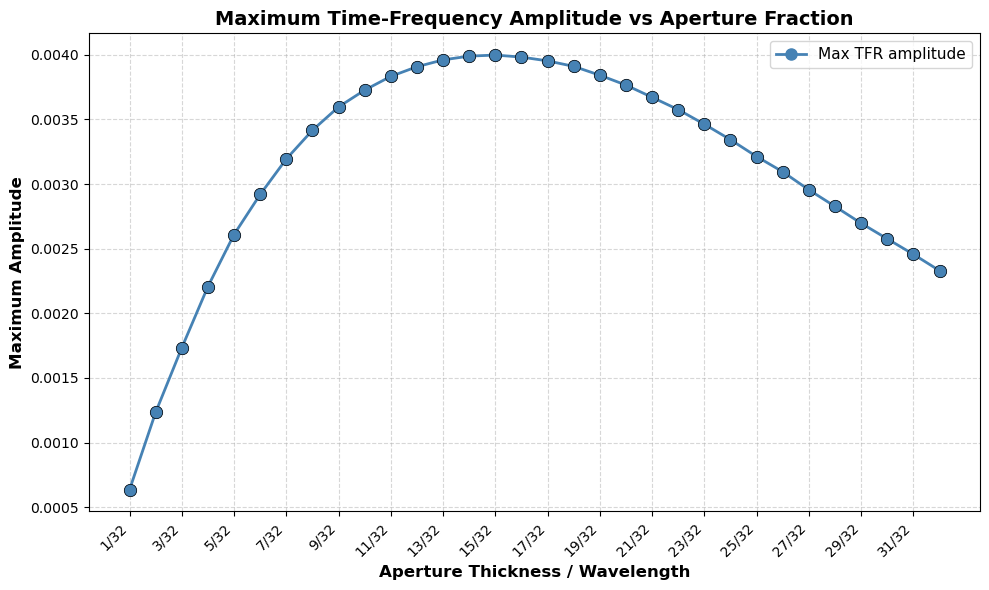


Summary:
  Min max amplitude: 6.357e-04 at aperture 0.0312
  Max max amplitude: 3.997e-03 at aperture 0.4688
  Mean max amplitude: 3.144e-03


In [28]:
from obspy.signal.tf_misfit import cwt
import numpy as np
import matplotlib.pyplot as plt

if 'wiggle_matrix' not in globals() or 'wiggle_dt' not in globals():
    raise RuntimeError('Run Cell 14 first to create wiggle matrices.')

# TFR parameters
fmin = 1e8
fmax = 8e9
nf = 100
w0 = 6

dt = wiggle_dt
n_traces = wiggle_matrix.shape[1]
max_amps = []
aperture_fracs = []

# Loop over all traces
for trace_idx in range(n_traces):
    st1 = wiggle_matrix[:, trace_idx]
    time_vec = np.arange(st1.size) * dt
    
    # Compute CWT
    tf_complex = cwt(st1, dt=dt, w0=w0, fmin=fmin, fmax=fmax, nf=nf)
    tf_amp = np.abs(tf_complex)
    
    # Find max amplitude in time-frequency domain
    max_tf_amp = np.max(tf_amp)
    max_amps.append(max_tf_amp)
    aperture_fracs.append(wiggle_aperture_fraction[trace_idx])
    
    print(f'Trace {trace_idx:2d} (aperture {wiggle_aperture_fraction[trace_idx]:.4f}): '
          f'max TFR amplitude = {max_tf_amp:.3e}')

max_amps = np.asarray(max_amps)
aperture_fracs = np.asarray(aperture_fracs)

# Sort by aperture fraction for cleaner plot
sort_idx = np.argsort(aperture_fracs)
aperture_fracs_sorted = aperture_fracs[sort_idx]
max_amps_sorted = max_amps[sort_idx]

# Plot maximum amplitude vs aperture fraction
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aperture_fracs_sorted, max_amps_sorted, 'o-', linewidth=2, markersize=8, color='steelblue', label='Max TFR amplitude')
ax.scatter(aperture_fracs_sorted, max_amps_sorted, s=80, color='steelblue', zorder=5, edgecolors='black', linewidths=0.5)

ax.set_xlabel('Aperture Thickness / Wavelength', fontsize=12, fontweight='bold')
ax.set_ylabel('Maximum Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Maximum Time-Frequency Amplitude vs Aperture Fraction', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

# Format x-axis with fraction notation
tick_nums = np.arange(1, 33)
tick_positions = tick_nums / 32.0
tick_labels = [f'{n}/32' if n < 32 else '1' for n in tick_nums]
ax.set_xticks(tick_positions[::2])  # Show every other tick for clarity
ax.set_xticklabels(tick_labels[::2], rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f'\nSummary:')
print(f'  Min max amplitude: {max_amps.min():.3e} at aperture {aperture_fracs[np.argmin(max_amps)]:.4f}')
print(f'  Max max amplitude: {max_amps.max():.3e} at aperture {aperture_fracs[np.argmax(max_amps)]:.4f}')
print(f'  Mean max amplitude: {max_amps.mean():.3e}')


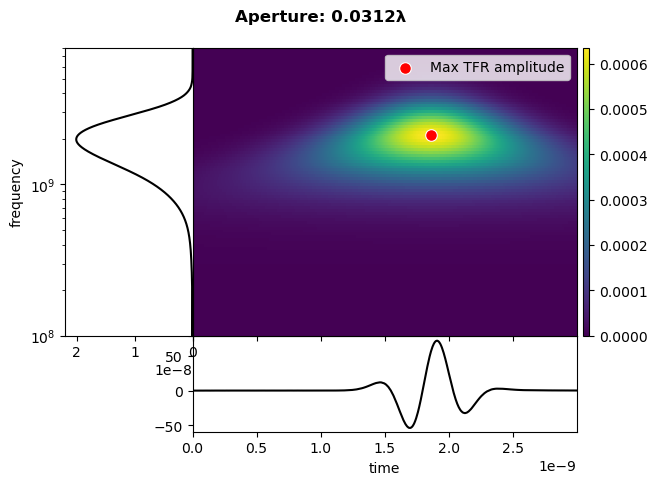

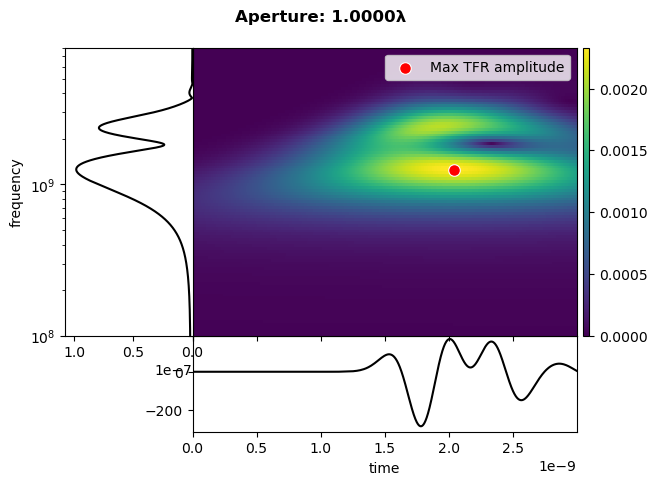

In [41]:
from obspy.signal.tf_misfit import plot_tfr, cwt
import numpy as np
import matplotlib.pyplot as plt

if 'wiggle_matrix' not in globals() or 'wiggle_dt' not in globals():
    raise RuntimeError('Run Cell 14 first to create wiggle matrices.')

# TFR parameters
fmin = 1e8
fmax = 8e9
nf = 100
w0 = 6

dt = wiggle_dt
trace_thinnest = 0    # 1/32λ
trace_thickest = 31   # 1λ

# Function to compute TFR max picks
def compute_tfr_picks(trace_data, dt, fmin, fmax, nf, w0):
    tf_complex = cwt(trace_data, dt=dt, w0=w0, fmin=fmin, fmax=fmax, nf=nf)
    tf_amp = np.abs(tf_complex)
    max_flat_idx = int(np.argmax(tf_amp))
    max_f_idx, max_t_idx = np.unravel_index(max_flat_idx, tf_amp.shape)
    freq_vec = np.logspace(np.log10(fmin), np.log10(fmax), nf)
    time_vec = np.arange(trace_data.size) * dt
    return {
        'tf_amp': tf_amp,
        'max_f_idx': max_f_idx,
        'max_t_idx': max_t_idx,
        'max_f': freq_vec[max_f_idx],
        'max_t': time_vec[max_t_idx],
        'max_val': tf_amp[max_f_idx, max_t_idx],
        'freq_vec': freq_vec,
        'time_vec': time_vec
    }

# Compute for both traces
st_thin = wiggle_matrix[:, trace_thinnest]
st_thick = wiggle_matrix[:, trace_thickest]
ap_thin = wiggle_aperture_fraction[trace_thinnest]
ap_thick = wiggle_aperture_fraction[trace_thickest]

picks_thin = compute_tfr_picks(st_thin, dt, fmin, fmax, nf, w0)
picks_thick = compute_tfr_picks(st_thick, dt, fmin, fmax, nf, w0)

# Generate TFR plots
fig_thin = plot_tfr(st_thin, dt=dt, fmin=fmin, fmax=fmax, fft_zero_pad_fac=5000, show=False)
fig_thick = plot_tfr(st_thick, dt=dt, fmin=fmin, fmax=fmax, fft_zero_pad_fac=5000, show=False)

# Add markers to both figures
for fig, picks, aperture_val in [(fig_thin, picks_thin, ap_thin), 
                                  (fig_thick, picks_thick, ap_thick)]:
    heat_axes = [ax for ax in fig.axes if len(ax.collections) > 0 or len(ax.images) > 0]
    tfr_ax = next((ax for ax in heat_axes if ax.get_yscale() == 'log'), heat_axes[0])
    tfr_ax.scatter(
        [picks['max_t']], [picks['max_f']],
        color='red', s=70, zorder=12,
        edgecolors='white', linewidths=0.8,
        label='Max TFR amplitude'
    )
    tfr_ax.legend(loc='upper right')
    fig.suptitle(f'Aperture: {aperture_val:.4f}λ', fontsize=12, fontweight='bold', y=0.98)

plt.show()

# Print comparison statistics
print('='*70)
print('COMPARISON: Thinnest (1/32λ) vs Thickest (1λ) Fracture')
print('='*70)
print(f'\nTHINNEST FRACTURE (1/32λ = {ap_thin:.4f}):')
print(f'  Max TFR amplitude: {picks_thin["max_val"]:.3e}')
print(f'  at frequency: {picks_thin["max_f"]/1e9:.3f} GHz')
print(f'  at time:      {picks_thin["max_t"]*1e9:.3f} ns')

print(f'\nTHICKEST FRACTURE (1λ = {ap_thick:.4f}):')
print(f'  Max TFR amplitude: {picks_thick["max_val"]:.3e}')
print(f'  at frequency: {picks_thick["max_f"]/1e9:.3f} GHz')
print(f'  at time:      {picks_thick["max_t"]*1e9:.3f} ns')

amplitude_ratio = picks_thick['max_val'] / picks_thin['max_val']
frequency_diff = (picks_thick['max_f'] - picks_thin['max_f']) / 1e9
time_diff = (picks_thick['max_t'] - picks_thin['max_t']) * 1e9

print(f'\nDIFFERENCES:')
print(f'  Amplitude ratio (thick/thin): {amplitude_ratio:.2f}x')
print(f'  Frequency difference: {frequency_diff:+.3f} GHz')
print(f'  Time difference: {time_diff:+.3f} ns')
print('='*70)
